# Libraries

In [63]:
import re
import os
import numpy as np
from astropy.io import ascii
from astropy.io import fits
from astropy.table import Table
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
from io import StringIO
from matplotlib.ticker import AutoMinorLocator
from astropy.constants import L_sun
from matplotlib import gridspec
import astropy.units as u
from math import pi
import gc
from matplotlib.ticker import ScalarFormatter
import matplotlib.colors as mcolors
import matplotlib.patheffects as pe
from astropy.table import Column
from scipy.stats import bootstrap

from __future__ import annotations
import os
import json
from astropy.cosmology import FlatwCDM

import pymultinest
import corner
from getdist import plots, MCSamples
import scipy.optimize as op
from scipy import stats
from scipy.stats import norm
from astropy.time import Time
import matplotlib.dates as mdates

# Visualizacion

In [2]:
Galaxy = 'M81'
Method = 'CEPHEIDS'

with fits.open('modulus_tracker.fits') as hdulist:
    
    # Iterar sobre cada HDU en la lista
    for hdu in hdulist:
        header = hdu.header
        
        # Aplicar los criterios de búsqueda
        # Verificar si 'EXTNAME' existe Y si 'TELESCOP' existe y coincide
        if ('EXTNAME' in header and header['EXTNAME'] == Galaxy) and \
           ('METHOD' in header and header['METHOD'] == Method):
            
            # Si ambos criterios coinciden, hemos encontrado nuestro HDU
            hdu_encontrado = hdu
            print(f"\nHDU número {hdulist.index(hdu)}.\n")
            Tabla = Table.read(hdu)
            #print(Tabla)
            # Puedes salir del bucle si solo esperas uno
            break 
    
    # 3. Usar el HDU encontrado
    if hdu_encontrado is not None:
        print("\nCabecera del HDU:\n")
        print(repr(hdu_encontrado.header)) # Imprime una representación completa de la cabecera
        # Aquí puedes acceder a los datos: hdu_encontrado.data
    else:
        print("\nNo se encontró ningún HDU que coincida con ambos criterios.")

Tabla


HDU número 7.


Cabecera del HDU:

XTENSION= 'BINTABLE'           / binary table extension                         
BITPIX  =                    8 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                 1087 / length of dimension 1                          
NAXIS2  =                   15 / length of dimension 2                          
PCOUNT  =                    0 / number of group parameters                     
GCOUNT  =                    1 / number of groups                               
TFIELDS =                   18 / number of table fields                         
METHOD  = 'CEPHEIDS'           / Cepheids PLR method                            
EXTNAME = 'M81     '           / Name of Host Galaxy                            
TTYPE1  = 'RefCode '           / Article's RefCode                              
TFORM1  = '40A     '                                                     

RefCode,Citation,Band,mu_0,e_R,e_S,e_T,Category,Ncef,Zcorr,zeroP,Rank,Year,Date,Comments,Author,ADS_date,JD
str40,str40,str40,float64,float64,float64,float64,int64,int64,bool,str20,int64,int64,str12,str800,str50,str12,float64
2000ApJ...529..745F,Ferrarese et al.2000,W(VI),27.8,0.08,--,--,1,30,False,LMC,1,2000,2024,They calculate gamma.,Valencia et al.2024,2000-02-00,2451575.5
2001ApJ...548..564W,Willick & Batra 2001,W(VI),27.66,0.09,--,--,1,25,False,LMC,1,2001,2024,They do not apply metallicity correction.,Valencia et al.2024,2001-02-00,2451941.5
2001ApJ...549..721M,Macri et al.2001,H,27.91,0.08,--,--,1,6,True,LMC,1,2001,2024,They use the H band.,Valencia et al.2024,2001-03-00,2451969.5
2001ApJ...553...47F,Freedman et al.2001,W(VI),27.75,0.08,--,--,1,17,False,LMC,1,2001,2024,No specific comments on the publication.,Valencia et al.2024,2001-05-00,2452030.5
2001ApJ...553...47F,Freedman et al.2001,W(VI),27.8,0.08,--,--,1,17,True,LMC,1,2001,2024,They apply metallicity correction.,Valencia et al.2024,2001-05-00,2452030.5
2002A&A...389...19P,"Paturel, G. et al.2002",W(VI),27.66,0.08,--,--,1,92,False,GC,1,2002,2024,They use data from Paurel et al. 2002 but with HIPPARCOS calibration.,Valencia et al.2024,2002-07-00,2452456.5
2003A&A...411..361K,"Kanbur, S. M. et al.2003",W(VI),27.79,0.09,--,--,1,17,False,LMC,1,2003,2024,Calculate metallicity correction but do not add error.,Valencia et al.2024,2003-12-00,2452974.5
2003A&A...411..361K,"Kanbur, S. M. et al.2003",W(VI),27.85,0.1,--,--,1,17,False,GC,1,2003,2024,Calculate metallicity correction but do not add error.,Valencia et al.2024,2003-12-00,2452974.5
2004ApJ...608...42S,Sakai et al.2004,BVRI,27.75,0.08,--,--,1,-1,False,LMC,1,2004,2024,Calculate gamma from TRGB.,Valencia et al.2024,2004-06-00,2453157.5


In [3]:
S = fits.open('modulus_tracker.fits')
gal_host = 12
P = Table.read(S[gal_host])
print(S[gal_host].header['EXTNAME'],' - ',S[gal_host].header['METHOD'])
#P = P[(P['Zcorr']==True)  &  (P['e_T']>= 0)]
#N_dat = len(P)
#if N_dat > 0:
#    G1_m, G1_e, Galaxia = np.array(P['mu_0']), np.array(P['e_T']), S[gal_host].header['EXTNAME']
#    mu_w, sigma_w = round(weighted_average(G1_m,G1_e),3), round(weighted_error(G1_e),3)
#    print(N_dat,mu_w,sigma_w)
P

MRK116  -  TRGB


RefCode,Citation,Band,mu_0,e_R,Rank,Year,Date,Comments,Author,ADS_date,JD
str40,str40,str40,float64,float64,int64,int64,str12,str800,str50,str12,float64
2007ApJ...667L.151A,Aloisi et al.2007,I(VI),31.3,0.17,1,2007,2024,There are no specific comments on the publication.,Valencia et al.2024,2007-10-00,2454374.5


In [4]:
S.info()

Filename: modulus_tracker.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       6   (1, 1)   float64   
  1  IC0010        1 BinTableHDU     62   1R x 18C   [40A, 40A, 40A, D, D, D, D, K, K, L, 20A, K, K, 12A, 800A, 50A, 12A, D]   
  2  IC0010        1 BinTableHDU     38   13R x 12C   [40A, 40A, 40A, D, D, K, K, 12A, 800A, 50A, 12A, D]   
  3  IC2574        1 BinTableHDU     62   0R x 18C   [40A, 40A, 40A, D, D, D, D, K, K, L, 20A, K, K, 12A, 800A, 50A, 12A, D]   
  4  IC2574        1 BinTableHDU     38   5R x 12C   [40A, 40A, 40A, D, D, K, K, 12A, 800A, 50A, 12A, D]   
  5  M33           1 BinTableHDU     62   14R x 18C   [40A, 40A, 40A, D, D, D, D, K, K, L, 20A, K, K, 12A, 800A, 50A, 12A, D]   
  6  M33           1 BinTableHDU     38   15R x 12C   [40A, 40A, 40A, D, D, K, K, 12A, 800A, 50A, 12A, D]   
  7  M81           1 BinTableHDU     62   15R x 18C   [40A, 40A, 40A, D, D, D, D, K, K, L, 20A, K, K, 12A, 800A, 50A, 12A, D]   
  8  

# Functions

In [5]:
def weighted_average(modulus,error):
    modulus,error = np.array(modulus),np.array(error)
    err_sq_inv = 1 / ((error)**2)
    num = np.sum(err_sq_inv * modulus)
    dem = np.sum(err_sq_inv)

    return num/dem

def weighted_error(error):
    error = np.array(error)
    err_sq_inv = 1 / ((error)**2)
    dem = np.sum(err_sq_inv)

    return 1 / np.sqrt(dem)

def bootstrap_error2(modulus,error,N=200000,group = '',Galaxy=''):

    PATH = f'BR/{group}/{Galaxy}.txt'

    if os.path.exists(PATH) == True:
        bootstrap_statistics = np.loadtxt(PATH)
        print(f'Reading bootstrap for {Galaxy}\n')
    if os.path.exists(PATH) == False:
        print(f'Running bootstrap for {Galaxy}\n')
        modulus,error = np.array(modulus),np.array(error)
        size = len(modulus)

        n_bootstraps = N  # Number of bootstrap iterations
        bootstrap_statistics = []

        for i in range(n_bootstraps):
            # Create a resample with replacement, same size as original data
            bootstrap_sample = np.random.choice(size, size=size, replace=True)

            modulus_sample = modulus[bootstrap_sample]
            error_sample = error[bootstrap_sample]

            sample_mean = weighted_average(modulus_sample,error_sample)
            bootstrap_statistics.append(sample_mean)

        bootstrap_statistics = np.array(bootstrap_statistics)

        np.savetxt(fname = PATH, X = bootstrap_statistics)

    N_dist = len(bootstrap_statistics)

    br_mean = np.mean(bootstrap_statistics)

    quad_br = (bootstrap_statistics-br_mean)**2
    
    lower_bound = np.percentile(bootstrap_statistics, 15.87)
    upper_bound = np.percentile(bootstrap_statistics, 84.13)

    return [np.sqrt(((1)/(N_dist-1)) * np.sum(quad_br)),
           [br_mean - lower_bound, upper_bound - br_mean],
            bootstrap_statistics]

    
def cochran_error(modulus,error):
    Mu_i,Er_i = np.array(modulus),np.array(error)
    n = len(Mu_i)
    w_i = 1 / ((Er_i)**2)

    Mu_w = weighted_average(Mu_i,Er_i)
    w_mean = np.mean(w_i)

    s1 = n / ((n-1) * (np.sum(w_i))**2)
    s2 = (w_i * Mu_i  - (w_mean * Mu_w))**2
    s3 = (w_i - w_mean) * ((w_i*Mu_i) - (w_mean*Mu_w)) 
    s4 = (w_i - w_mean)**2

    return np.sqrt(s1 * (np.sum(s2) - (2 * Mu_w * np.sum(s3)) +    (Mu_w**2 * np.sum(s4)) ) )


def nestedsampling_error(modulus,error,steps=10000, Name='', group = ''):

    def prior_transform(x):
        mu = 20 * x + 20
        return mu
    
    def lnlike(theta, m, merr):
        mu_pi = theta
        R = (mu_pi - m)
        W = 1.0/(merr**2)
        xsq = np.sum(R**2 * W)
        L = -0.5*xsq
        return L
    
    def loglike_for_mnest(theta):
        return lnlike(theta, modulus, error)
    
    outdir = os.path.join('NS', group)
    os.makedirs(outdir, exist_ok=True)
    prefix = os.path.join(outdir, Name)

    n_dims = 1
    result = pymultinest.solve(
        LogLikelihood=loglike_for_mnest,
        Prior=prior_transform,
        n_dims=n_dims,
        outputfiles_basename=prefix,
        evidence_tolerance=0.5,
        n_live_points=steps,
        multimodal=True,
        verbose=False,
    )

    samples = result["samples"] 
    T_sample = samples.T


    # calcula loglike para cada muestra
    logL = np.array([loglike_for_mnest(s) for s in samples])

    # punto MAP (aprox): el de mayor logL
    #theta_map = samples[np.argmax(logL)]

    # chi^2 en MAP
    chi2_map = -2.0*np.max(logL)

    N = len(modulus)   # número de datos
    k = n_dims         # parámetros del modelo
    nu = N - k
    chi2_red = chi2_map / nu

    sigma2_corr = T_sample.std() * chi2_red

    return [T_sample.std(),sigma2_corr]

# Tests

#### sm_r (Sin metalicidad solo aleatorios)

In [6]:
if os.path.exists('sm_r.csv'):
    DF = pd.read_csv('sm_r.csv')
else:
    S = fits.open('modulus_tracker.fits')
    sm_r = []
    sm_r =['Galaxia','N_dat','mu_w','sigma_w','sigma_br','sigma_C','sigma_cl+','sigma_cl-','sigma_L','sigma_Lcorr']

    for i in range(1,64):

        gal_host = i

        T = Table.read(S[gal_host])

        if (S[gal_host].header['METHOD'] == 'CEPHEIDS') and (len(T)>0):

            T = T[(T['Zcorr']==False) & (T['e_R']>= 0)]

            G1_m = np.array(T['mu_0'])
            G1_e = np.array(T['e_R'])
            Galaxia = S[gal_host].header['EXTNAME']
            N_dat = len(T)
            
            
            if N_dat == 0:
                print(f"No data for {Galaxia}")
            if N_dat == 1:
                #print(N_dat)
                mu_w = weighted_average(G1_m,G1_e)
                sigma_w = weighted_error(G1_e)
                sm_r.append([Galaxia,N_dat,mu_w,sigma_w,'--','--','--','--','--','--'])        
            if N_dat > 1:
                #print(N_dat)
                mu_w = weighted_average(G1_m,G1_e)
                sigma_w = weighted_error(G1_e)
                sigma_br,sigma_cl,Br_stats = bootstrap_error2(modulus = G1_m,error = G1_e,N=200000,group='sm_r',Galaxy=Galaxia)
                sigma_br = sigma_br 
                sigma_cl[0] = sigma_cl[0]
                sigma_cl[1] = sigma_cl[1]
                sigma_C = cochran_error(G1_m,G1_e)
                sigma_L, sigma_Lcorr = nestedsampling_error(G1_m,G1_e,Name=Galaxia,group = 'sm_r')
                sm_r.append([Galaxia,N_dat,mu_w,sigma_w,sigma_br,sigma_C,sigma_cl[0],sigma_cl[1],sigma_L,sigma_Lcorr])

    S.close()

    DF = pd.DataFrame(data = sm_r[10:],columns = sm_r[0:10])
    DF.to_csv('sm_r.csv')

DF

,Unnamed: 0,Galaxia,N_dat,mu_w,sigma_w,sigma_br,sigma_C,sigma_cl+,sigma_cl-,sigma_L,sigma_Lcorr
0,0,IC0010,1,24.100000,0.190000,--,--,--,--,--,--
1,1,M33,10,24.579050,0.011776,0.0953575322980271,0.10274899005067833,0.10680206975823126,0.11066932608176216,0.011776117320813344,0.2863165890083149
2,2,M81,11,27.755496,0.023216,0.014671234572621554,0.014547330632287223,0.014298599105199372,0.014290303431021556,0.023177367437724472,0.01032643751924522
3,3,M101,7,29.158436,0.028598,0.04402230136459406,0.0484068613593364,0.04668060070174107,0.05163124407073738,0.028527068237959675,0.054062457980448474
4,4,MRK116,1,31.380000,0.170000,--,--,--,--,--,--
5,5,NGC0925,6,29.780201,0.022699,0.012464931989973156,0.013023451550885795,0.011962553869576453,0.012771523082424352,0.022695770425494144,0.008445584995920146
6,6,NGC2403,1,27.480000,0.100000,--,--,--,--,--,--
7,7,NGC2541,5,30.322696,0.028373,0.0295108298942239,0.03319776358475411,0.028136110507301026,0.029677104113108754,0.028392104927682668,0.032876700721147976
8,8,NGC3198,6,30.758172,0.027043,0.022274197842388113,0.023854922549857563,0.02154489758752831,0.01962365999007787,0.027073706587693095,0.02313831012476753
9,9,NGC3319,6,30.647140,0.035740,0.03580009712858188,0.03856112012955415,0.03806787599147299,0.03420919150510926,0.035644305472226204,0.044590803824921095


#### cm_r (Con metalicidad solo aleatorios)

In [7]:
if os.path.exists('cm_r.csv'):
    DF = pd.read_csv('cm_r.csv')
else:
    S = fits.open('modulus_tracker.fits')
    cm_r = []
    cm_r =['Galaxia','N_dat','mu_w','sigma_w','sigma_br','sigma_C','sigma_cl+','sigma_cl-','sigma_L','sigma_Lcorr']

    for i in range(1,64):

        gal_host = i

        T = Table.read(S[gal_host])

        if (S[gal_host].header['METHOD'] == 'CEPHEIDS') and (len(T)>0):

            T = T[(T['Zcorr']==True) & (T['e_R']>= 0)]

            G1_m = np.array(T['mu_0'])
            G1_e = np.array(T['e_R'])
            Galaxia = S[gal_host].header['EXTNAME']
            N_dat = len(T)
            
            
            if N_dat == 0:
                print(f"No data for {Galaxia}")
            if N_dat == 1:
                #print(N_dat)
                mu_w = weighted_average(G1_m,G1_e)
                sigma_w = weighted_error(G1_e)
                cm_r.append([Galaxia,N_dat,mu_w,sigma_w,'--','--','--','--','--','--'])        
            if N_dat > 1:
                #print(N_dat)
                mu_w = weighted_average(G1_m,G1_e)
                sigma_w = weighted_error(G1_e)
                sigma_br,sigma_cl,Br_stats = bootstrap_error2(modulus = G1_m,error = G1_e,N=200000,group='cm_r',Galaxy=Galaxia)
                sigma_br = sigma_br 
                sigma_cl[0] = sigma_cl[0]
                sigma_cl[1] = sigma_cl[1]
                sigma_C = cochran_error(G1_m,G1_e)
                sigma_L, sigma_Lcorr = nestedsampling_error(G1_m,G1_e,Name=Galaxia,group = 'cm_r')
                cm_r.append([Galaxia,N_dat,mu_w,sigma_w,sigma_br,sigma_C,sigma_cl[0],sigma_cl[1],sigma_L,sigma_Lcorr])

    S.close()

    DF = pd.DataFrame(data = cm_r[10:],columns = cm_r[0:10])
    DF.to_csv('cm_r.csv')

DF

,Unnamed: 0,Galaxia,N_dat,mu_w,sigma_w,sigma_br,sigma_C,sigma_cl+,sigma_cl-,sigma_L,sigma_Lcorr
0,0,M33,4,24.622201,0.008837,0.003262,0.000538,0.001338,0.000366,0.008735,0.000275
1,1,M81,4,27.835294,0.045315,0.027960,0.032589,0.033707,0.032428,0.045452,0.019453
2,2,M101,6,29.170148,0.026293,0.039888,0.032154,0.031322,0.032637,0.026287,0.090543
3,3,NGC0925,3,29.826667,0.026667,0.009665,0.011759,0.007430,0.012570,0.026504,0.004141
4,4,NGC2403,2,27.506154,0.083205,0.040317,0.046864,0.065454,0.044546,0.082854,0.030847
5,5,NGC2541,2,30.352459,0.038411,0.088908,0.120935,0.113883,0.136117,0.038504,0.394511
6,6,NGC3198,2,30.750000,0.056569,0.035356,0.050000,0.050090,0.049910,0.056627,0.044240
7,7,NGC3319,2,30.687034,0.059793,0.042520,0.059175,0.063474,0.056526,0.059076,0.058669
8,8,NGC4258,11,29.344302,0.003914,0.037511,0.003063,0.021746,0.006262,0.003930,0.024092
9,9,NGC6822,10,23.377443,0.009518,0.024482,0.024957,0.024809,0.024624,0.009468,0.044380


#### sm_t (Sin metalicidad totales)

In [8]:
if os.path.exists('sm_t.csv'):
    DF = pd.read_csv('sm_t.csv')
else:
    S = fits.open('modulus_tracker.fits')
    sm_t = []
    sm_t =['Galaxia','N_dat','mu_w','sigma_w','sigma_br','sigma_C','sigma_cl+','sigma_cl-','sigma_L','sigma_Lcorr']

    for i in range(1,64):

        gal_host = i

        T = Table.read(S[gal_host])

        if (S[gal_host].header['METHOD'] == 'CEPHEIDS') and (len(T)>0):

            T = T[(T['Zcorr']==False)  &  (T['e_T']>= 0)]

            G1_m = np.array(T['mu_0'])
            G1_e = np.array(T['e_T'])
            Galaxia = S[gal_host].header['EXTNAME']
            N_dat = len(T)
            
            
            if N_dat == 0:
                print(f"No data for {Galaxia}")
            if N_dat == 1:
                #print(N_dat)
                mu_w = weighted_average(G1_m,G1_e)
                sigma_w = weighted_error(G1_e)
                sm_t.append([Galaxia,N_dat,mu_w,sigma_w,'--','--','--','--','--','--'])        
            if N_dat > 1:
                #print(N_dat)
                mu_w = weighted_average(G1_m,G1_e)
                sigma_w = weighted_error(G1_e)
                sigma_br,sigma_cl,Br_stats = bootstrap_error2(modulus = G1_m,error = G1_e,N=200000,group='sm_t',Galaxy=Galaxia)
                sigma_br = sigma_br 
                sigma_cl[0] = sigma_cl[0]
                sigma_cl[1] = sigma_cl[1]
                sigma_C = cochran_error(G1_m,G1_e)
                sigma_L, sigma_Lcorr = nestedsampling_error(G1_m,G1_e,Name=Galaxia,group = 'sm_t')
                sm_t.append([Galaxia,N_dat,mu_w,sigma_w,sigma_br,sigma_C,sigma_cl[0],sigma_cl[1],sigma_L,sigma_Lcorr])

    S.close()

    DF = pd.DataFrame(data = sm_t[10:],columns = sm_t[0:10])
    DF.to_csv('sm_t.csv')


DF

,Unnamed: 0,Galaxia,N_dat,mu_w,sigma_w,sigma_br,sigma_C,sigma_cl+,sigma_cl-,sigma_L,sigma_Lcorr
0,0,M33,1,24.520000,0.191050,--,--,--,--,--,--
1,1,M81,1,27.780000,0.148661,--,--,--,--,--,--
2,2,M101,1,29.040000,0.186815,--,--,--,--,--,--
3,3,NGC4258,1,29.280000,0.042426,--,--,--,--,--,--
4,4,NGC6822,3,23.318015,0.054922,0.03274236559435343,0.026577232905715918,0.03639081789898668,0.02620514806382701,0.055117734140939165,0.015088914754775617


#### cm_t (Con metalicidad totales)

In [9]:
if os.path.exists('cm_t.csv'):
    DF = pd.read_csv('cm_t.csv')
else:
    S = fits.open('modulus_tracker.fits')
    cm_t = []
    cm_t =['Galaxia','N_dat','mu_w','sigma_w','sigma_br','sigma_C','sigma_cl+','sigma_cl-','sigma_L','sigma_Lcorr']

    for i in range(1,64):

        gal_host = i

        T = Table.read(S[gal_host])

        if (S[gal_host].header['METHOD'] == 'CEPHEIDS') and (len(T)>0):

            T = T[(T['Zcorr']==True)  &  (T['e_T']>= 0)]

            G1_m = np.array(T['mu_0'])
            G1_e = np.array(T['e_T'])
            Galaxia = S[gal_host].header['EXTNAME']
            N_dat = len(T)
            
            
            if N_dat == 0:
                print(f"No data for {Galaxia}")
            if N_dat == 1:
                mu_w = weighted_average(G1_m,G1_e)
                sigma_w = weighted_error(G1_e)
                cm_t.append([Galaxia,N_dat,mu_w,sigma_w,'--','--','--','--','--','--'])        
            if N_dat > 1:
                mu_w = weighted_average(G1_m,G1_e)
                sigma_w = weighted_error(G1_e)
                sigma_br,sigma_cl,Br_stats = bootstrap_error2(modulus = G1_m,error = G1_e,N=200000,group='cm_t',Galaxy=Galaxia)
                sigma_br = sigma_br 
                sigma_cl[0] = sigma_cl[0]
                sigma_cl[1] = sigma_cl[1]
                sigma_C = cochran_error(G1_m,G1_e)
                sigma_L, sigma_Lcorr = nestedsampling_error(G1_m,G1_e,Name=Galaxia,group = 'cm_t')
                cm_t.append([Galaxia,N_dat,mu_w,sigma_w,sigma_br,sigma_C,sigma_cl[0],sigma_cl[1],sigma_L,sigma_Lcorr])

    S.close()

    DF = pd.DataFrame(data = cm_t[10:],columns = cm_t[0:10])
    DF.to_csv('cm_t.csv')

DF

,Unnamed: 0,Galaxia,N_dat,mu_w,sigma_w,sigma_br,sigma_C,sigma_cl+,sigma_cl-,sigma_L,sigma_Lcorr
0,0,M33,3,24.622607,0.024646,0.0036431810915986992,0.0015951410219341936,0.0018282533460194372,0.0011428179098302849,0.024814144410700015,0.000414304214093008
1,1,M81,1,27.800000,0.120416,--,--,--,--,--,--
2,2,M101,1,29.160000,0.089443,--,--,--,--,--,--
3,3,NGC0925,1,29.840000,0.089443,--,--,--,--,--,--
4,4,NGC2403,1,27.430000,0.170000,--,--,--,--,--,--
5,5,NGC2541,1,30.500000,0.100000,--,--,--,--,--,--
6,6,NGC3198,1,30.800000,0.113137,--,--,--,--,--,--
7,7,NGC3319,1,30.740000,0.113137,--,--,--,--,--,--
8,8,NGC4258,2,29.560000,0.084380,0.13407859108915515,0.11199999999963102,0.22821330000000017,0.1217866999999977,0.08478934291382192,0.2334088655367774
9,9,NGC6822,5,23.345343,0.032291,0.02378822707057839,0.02360939961154577,0.0299737617077227,0.024180381916767857,0.03238080957873395,0.010636930950173526


#### t_r (TRGB solo aleatorios)

In [10]:
if os.path.exists('t_r.csv'):
    DF = pd.read_csv('t_r.csv')
else:
    S = fits.open('modulus_tracker.fits')
    t_r = []
    t_r =['Galaxia','N_dat','mu_w','sigma_w','sigma_br','sigma_C','sigma_cl+','sigma_cl-','sigma_L','sigma_Lcorr']

    for i in range(1,64):

        gal_host = i

        T = Table.read(S[gal_host])

        if (S[gal_host].header['METHOD'] == 'TRGB') and (len(T)>0):
            G1_m = np.array(T['mu_0'])
            G1_e = np.array(T['e_R'])
            Galaxia = S[gal_host].header['EXTNAME']
            N_dat = len(T)

            if N_dat == 0:
                print(f"No data for {Galaxia}")
            if N_dat == 1:
                mu_w = weighted_average(G1_m,G1_e)
                sigma_w = weighted_error(G1_e)
                t_r.append([Galaxia,N_dat,mu_w,sigma_w,'--','--','--','--','--','--'])        
            if N_dat > 1:
                mu_w = weighted_average(G1_m,G1_e)
                sigma_w = weighted_error(G1_e)
                sigma_br,sigma_cl,Br_stats = bootstrap_error2(modulus = G1_m,error = G1_e,N=200000,group='t_r',Galaxy=Galaxia)
                sigma_br = sigma_br 
                sigma_cl[0] = sigma_cl[0]
                sigma_cl[1] = sigma_cl[1]
                sigma_C = cochran_error(G1_m,G1_e)
                sigma_L, sigma_Lcorr = nestedsampling_error(G1_m,G1_e,Name=Galaxia,group = 't_r')
                t_r.append([Galaxia,N_dat,mu_w,sigma_w,sigma_br,sigma_C,sigma_cl[0],sigma_cl[1],sigma_L,sigma_Lcorr])

    S.close()

    DF = pd.DataFrame(data = t_r[10:],columns = t_r[0:10])
    DF.to_csv('t_r.csv')


DF

,Unnamed: 0,Galaxia,N_dat,mu_w,sigma_w,sigma_br,sigma_C,sigma_cl+,sigma_cl-,sigma_L,sigma_Lcorr
0,0,IC0010,13,24.308866,0.011874,0.024991047405480096,0.025530571407204338,0.025160973235902162,0.025219420043359975,0.011867873645638785,0.04383594143762537
1,1,IC2574,5,27.918604,0.014743,0.014477758601428506,0.01597290138980672,0.014871061331422908,0.015128938668574676,0.014828864533616905,0.014905029561507648
2,2,M33,15,24.706311,0.014811,0.030894560483642506,0.029643210431887185,0.029674479517307617,0.029798635475668078,0.014878799743284142,0.046741171566757785
3,3,M81,9,27.782926,0.013189,0.02467538669776605,0.021952531278327216,0.021951838885673425,0.022545665586672925,0.013308990595176767,0.04615042599626533
4,4,M101,26,29.267544,0.006395,0.014910579731964363,0.015260269946823307,0.01504649054652063,0.0150943269960635,0.006447379551606107,0.024580308192114566
5,5,MRK116,1,31.300000,0.170000,--,--,--,--,--,--
6,6,NGC2366,5,27.558570,0.020543,0.02093936807974261,0.01265007563921952,0.015107454169147161,0.012327315089450508,0.020332941575215355,0.010179527805059846
7,7,NGC2403,5,27.488114,0.025688,0.02333698013370006,0.02460216185790029,0.02334777707277169,0.02578789421019323,0.02571287246800975,0.016181434172244654
8,8,NGC4214,11,27.358982,0.017264,0.021111974240055034,0.020801424393238573,0.02325147107044856,0.021899703142938876,0.017248504386164154,0.012902808277986037
9,9,NGC4236,3,28.232726,0.089229,0.04885237524090946,0.016610852795128903,0.025439658870055837,0.012261990249580634,0.08821730698175992,0.01201374962611786


# Plots

  analysing data from NS/t_r/IC0010.txt
Reading bootstrap for IC0010



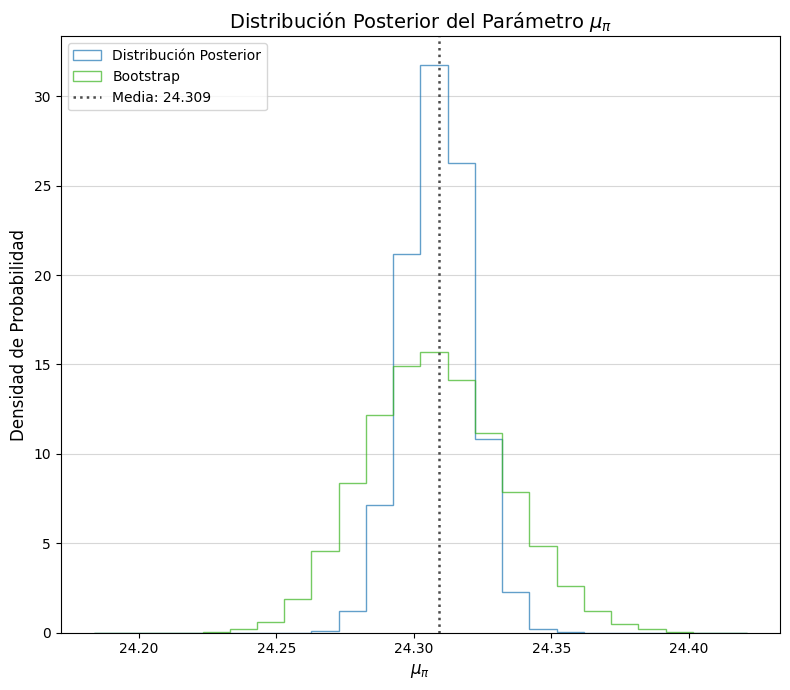

In [95]:
S = fits.open('modulus_tracker.fits')

Galaxia = 'IC0010'
GRUPO = 't_r'

if GRUPO == 'sm_r' or GRUPO == 'cm_r' or GRUPO == 'sm_t' or GRUPO == 'cm_t':
    metodo = 'CEPHEIDS'
if GRUPO == 't_r':
    metodo = 'TRGB'
    
for hdu in S:
    header = hdu.header
    
    # Aplicar los criterios de búsqueda
    # Verificar si 'EXTNAME' existe Y si 'TELESCOP' existe y coincide
    if ('EXTNAME' in header and header['EXTNAME'] == Galaxia) and \
        ('METHOD' in header and header['METHOD'] == metodo):
        # Si ambos criterios coinciden, hemos encontrado nuestro HDU
        hdu_encontrado = hdu
        P = Table.read(hdu)
        #print(Tabla)
        # Puedes salir del bucle si solo esperas uno
        break 

G1_m = np.array(P['mu_0'])
G1_e = np.array(P['e_R'])

n_dims = 1  # Tu único parámetro (mu_pi)
outdir = os.path.join('NS', GRUPO) 
prefix = os.path.join(outdir, Galaxia)

samples  = pymultinest.analyse.Analyzer(n_params = 1, outputfiles_basename=prefix)

mu_pi_samples = samples.get_equal_weighted_posterior()[:,0]

bootstrap_pahist = bootstrap_error2(modulus = G1_m,error = G1_e,N=200000,group=GRUPO,Galaxy=Galaxia)[2]

binS = np.histogram_bin_edges(bootstrap_pahist, bins='doane')

plt.figure(figsize=(8, 7))

# Plotear el histograma
# `density=True` normaliza el histograma para que el área bajo las barras sea 1, 
# haciendo que parezca una función de densidad de probabilidad.
plt.hist(mu_pi_samples, bins=binS, density=True, 
         color='#1f77b4', alpha=0.7, label='Distribución Posterior',histtype='step')

plt.hist(bootstrap_pahist, bins=binS, density=True, 
         color="#3ab41f", alpha=0.7, label='Bootstrap',histtype='step')

# --- 5. Añadir Información Clave (Media y Desviación Estándar) ---
mean_mu_pi = round(weighted_average(G1_m,G1_e),3)
#std_mu_pi = np.std(mu_pi_samples)

# Trazar la media (Estimación del parámetro)
plt.axvline(mean_mu_pi, color='black', linestyle='dotted', linewidth=1.8, alpha = 0.7, 
            label=f'Media: {mean_mu_pi:.3f}')

'''
std_mu_pi = 0.025
# Define los límites de 1-sigma
lower_limit = mean_mu_pi - std_mu_pi
upper_limit = mean_mu_pi + std_mu_pi

line_height = plt.ylim()[1] * 0.5  # 80% de la altura máxima del plot

# B. Dibujar la línea horizontal (la barra de 1-sigma)
plt.hlines(y=line_height, 
           xmin=lower_limit, 
           xmax=upper_limit, 
           color='red', alpha = 0.3,
           linewidth=1.5, #           label=f'$mu pm 1sigma$ ({std_mu_pi:.2f})')


# C. Dibujar las barras verticales de los límites (las cotas)
# Cota Inferior (-1 sigma)
plt.vlines(x=lower_limit, 
           ymin=line_height - (plt.ylim()[1]*0.02), # Pequeño offset para la barra vertical
           ymax=line_height + (plt.ylim()[1]*0.02), 
           color='red', alpha = 0.3,linestyles='-',
           linewidth=1.5)

# Cota Superior (+1 sigma)
plt.vlines(x=upper_limit, 
           ymin=line_height - (plt.ylim()[1]*0.02), 
           ymax=line_height + (plt.ylim()[1]*0.02), 
           color='red', alpha = 0.3,
           linewidth=1.5)


bootstrap_min = min(bootstrap_pahist)
bootstrap_max = max(bootstrap_pahist)
plt.xlim(mean_mu_pi-0.1,mean_mu_pi+0.1)
'''

# --- 6. Formato del Plot ---
plt.title(r'Distribución Posterior del Parámetro $\mu_\pi$', fontsize=14)
plt.xlabel(r'$\mu_\pi$', fontsize=12)
plt.ylabel('Densidad de Probabilidad', fontsize=12)
plt.legend(loc = 'upper left')
plt.grid(axis='y', alpha=0.5)
plt.tight_layout()
plt.show()

S.close()

In [12]:
DF_t = pd.read_csv('cm_r.csv')
DF_t = DF_t[DF_t['Galaxia'] == 'M33']
DF_t

,Unnamed: 0,Galaxia,N_dat,mu_w,sigma_w,sigma_br,sigma_C,sigma_cl+,sigma_cl-,sigma_L,sigma_Lcorr
0,0,M33,4,24.622201,0.008837,0.003262,0.000538,0.001338,0.000366,0.008735,0.000275


  analysing data from NS/cm_r/NGC4258.txt
Reading bootstrap for NGC4258



,Unnamed: 0,Galaxia,N_dat,mu_w,sigma_w,sigma_br,sigma_C,sigma_cl+,sigma_cl-,sigma_L,sigma_Lcorr
8,8,NGC4258,11,29.344302,0.003914,0.037511,0.003063,0.021746,0.006262,0.00393,0.024092


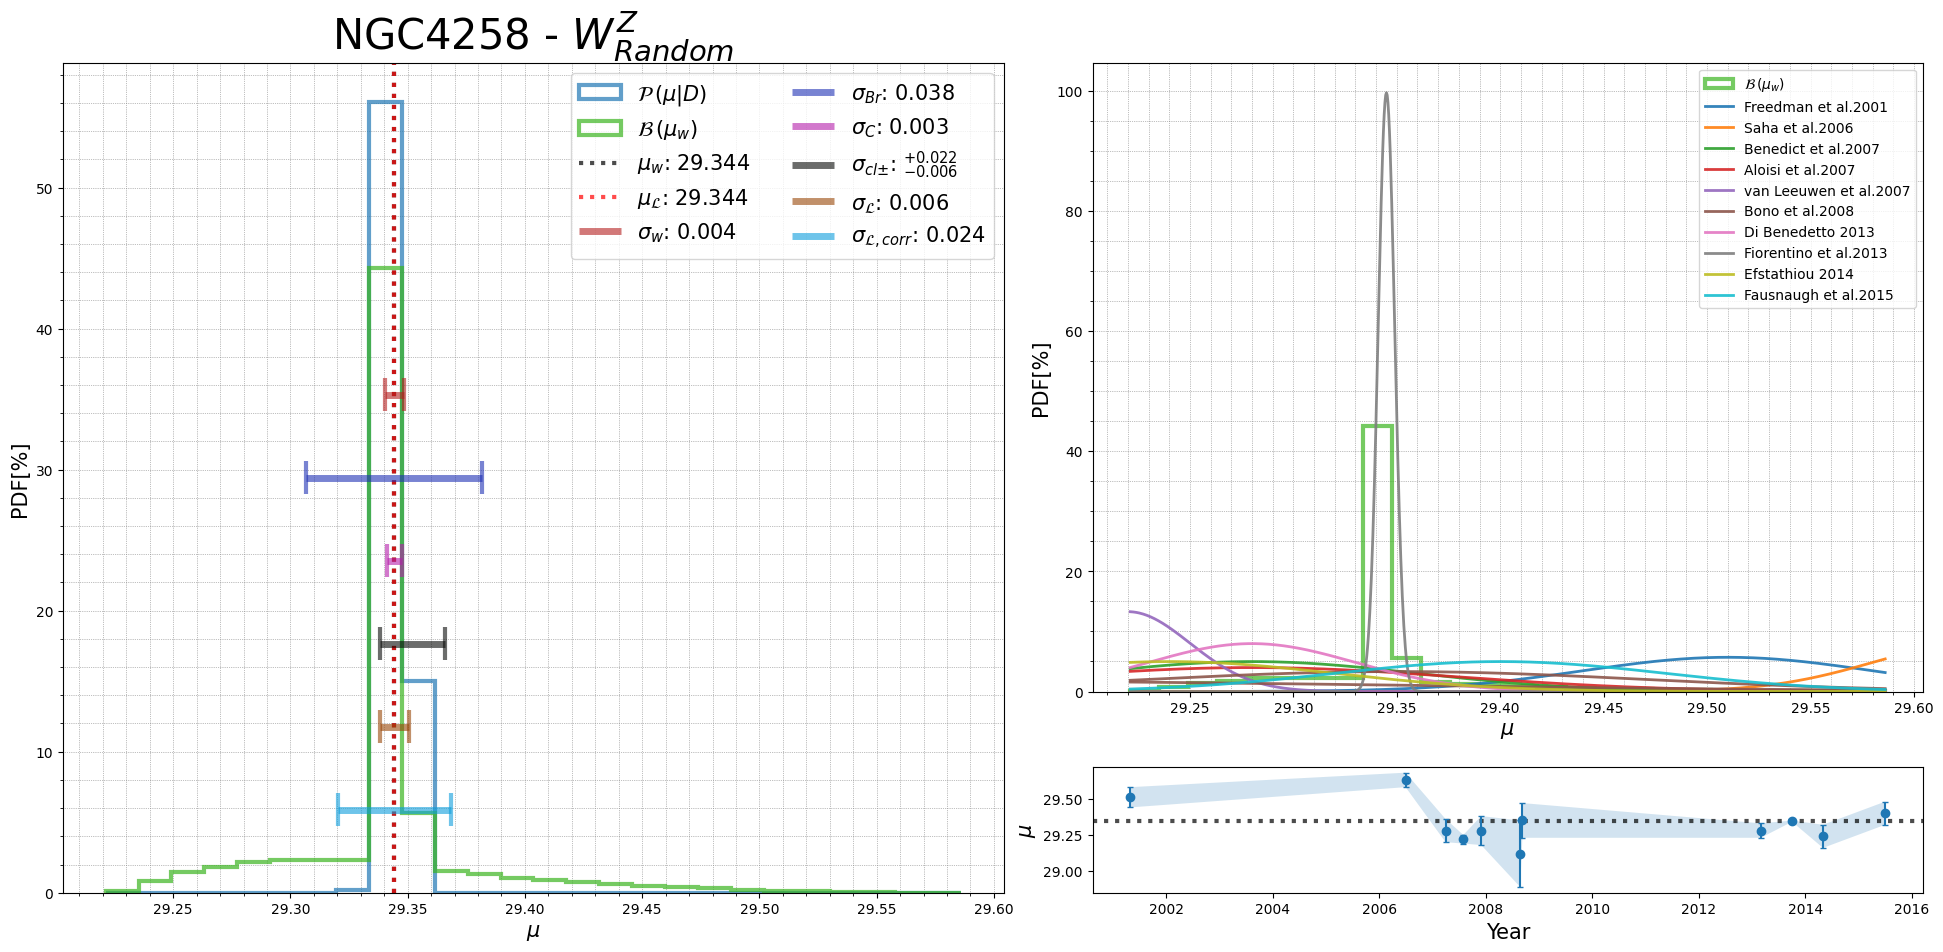

In [107]:
S = fits.open('modulus_tracker.fits')



Galaxia = 'NGC4258'
GRUPO = 'cm_r'

if GRUPO == 'sm_r' or GRUPO == 'cm_r' or GRUPO == 'sm_t' or GRUPO == 'cm_t':
    metodo = 'CEPHEIDS'
if GRUPO == 't_r':
    metodo = 'TRGB'
    
for hdu in S:
    header = hdu.header
    if ('EXTNAME' in header and header['EXTNAME'] == Galaxia) and \
        ('METHOD' in header and header['METHOD'] == metodo):
        hdu_encontrado = hdu
        T = Table.read(hdu)
        if GRUPO == 'sm_r':
            T = T[(T['Zcorr']==False) & (T['e_R']>= 0)]
            DF_t = pd.read_csv('sm_r.csv')
            DF_t = DF_t[DF_t['Galaxia'] == Galaxia]
            title_label = r'$W^{ \times Z}_{Random}$'
        if GRUPO == 'cm_r':
             T = T[(T['Zcorr']==True) & (T['e_R']>= 0)]
             DF_t = pd.read_csv('cm_r.csv')
             DF_t = DF_t[DF_t['Galaxia'] == Galaxia]
             title_label = r'$W^{Z}_{Random}$'
        if GRUPO == 'sm_t':
            T = T[(T['Zcorr']==False)  &  (T['e_T']>= 0)]
            DF_t = pd.read_csv('sm_t.csv')
            DF_t = DF_t[DF_t['Galaxia'] == Galaxia]
            title_label = r'$W^{ \times Z}_{Total}$'
        if GRUPO == 'cm_t':
            T = T[(T['Zcorr']==True)  &  (T['e_T']>= 0)]
            DF_t = pd.read_csv('cm_t.csv')
            DF_t = DF_t[DF_t['Galaxia'] == Galaxia]
            title_label = r'$W^{Z}_{Total}$'
        if GRUPO == 't_r':
            T = T
            DF_t = pd.read_csv('t_r.csv')
            DF_t = DF_t[DF_t['Galaxia'] == Galaxia]
            title_label = r'$T_{Random}$'
        break 


outdir = os.path.join('NS', GRUPO) 
prefix = os.path.join(outdir, Galaxia)
samples  = pymultinest.analyse.Analyzer(n_params = 1, outputfiles_basename=prefix)
mu_pi_samples = samples.get_equal_weighted_posterior()[:,0]
bootstrap_pahist = bootstrap_error2(modulus = G1_m,error = G1_e,N=200000,group=GRUPO,Galaxy=Galaxia)[2]
binS = np.histogram_bin_edges(bootstrap_pahist, bins='doane')


fig = plt.figure(figsize=(20, 10))

gs = gridspec.GridSpec(
    2, 2,
    figure=fig,
    width_ratios=[1.7, 1.5],
    height_ratios=[2.0, 0.4],
    wspace=0.1,
    hspace=0.2
)

gs.update(left=0.05, bottom=0.05, right=0.98, hspace=0.2)
ax1 = fig.add_subplot(gs[0:2, 0])

ax1.set_title(f'{Galaxia} - {title_label}', fontsize=30)
ax1.set_ylabel(r'PDF[%]', fontsize=15)
ax1.set_xlabel(r'$\mu$', fontsize=15)
ax1.grid(True, which="both", ls=":", color = 'gray', linewidth = 0.5)
ax1.minorticks_on()
ax1.hist(mu_pi_samples, bins=binS, density=True, 
         color='#1f77b4', alpha=0.7, label=r'$\mathcal{P} \,( \mu |D)$',histtype='step',linewidth=3)
ax1.hist(bootstrap_pahist, bins=binS, density=True, 
         color="#3ab41f", alpha=0.7, label=r'$\mathcal{B} \,( \mu_w)$',histtype='step',linewidth=3)

mu_w = float(DF_t['mu_w'].values[0])
mu_L = float(samples.get_stats()['modes'][0]['mean'][0])
sigma_w = float(DF_t['sigma_w'].values[0])
sigmabr = float(DF_t['sigma_br'].values[0])
sigmaC = float(DF_t['sigma_C'].values[0])
sigmacl_plus = float(DF_t['sigma_cl+'].values[0])
sigmacl_minus = float(DF_t['sigma_cl-'].values[0])
sigmaL = float(DF_t['sigma_L'].values[0])
sigmaLcorr = float(DF_t['sigma_Lcorr'].values[0])


ax1.axvline(mu_w, color='black', linestyle='dotted', linewidth=3, alpha = 0.7, 
            label=r'${\mu}_{w}$: ' + f'{mu_w:.3f}')
ax1.axvline(mu_L, color='red', linestyle='dotted', linewidth=3, alpha = 0.7, 
            label=r'${\mu}_{\mathcal{L}}$: ' + f'{mu_L:.3f}')


sigmas_loc = [0.6,0.5,0.4,0.3,0.2,0.1]
sigmas_color = ["#b41f1f","#1f30b4","#b41faa","#090a08","#994607","#0d9edc"]


for e in range(6):
    if e == 0:
        sigma_val = sigma_w
        label_sigma = r'$\sigma_{w}$'
    if e == 1:
        sigma_val = sigmabr
        label_sigma = r'$\sigma_{Br}$'
    if e == 2:
        sigma_val = sigmaC
        label_sigma = r'$\sigma_{C}$'
    if e == 3:
        #sigma_val = sigmacl_plus
        label_sigma = r'$\sigma_{cl{\pm}}$'
    if e == 4:
        sigma_val = sigmacl_minus
        label_sigma = r'$\sigma_{\mathcal{L}}$'
    if e == 5:
        sigma_val = sigmaLcorr
        label_sigma = r'$\sigma_{\mathcal{L},corr}$'

    s_loc = sigmas_loc[e]
    s_col = sigmas_color[e]

    line_height = ax1.get_ylim()[1] * sigmas_loc[e]
        
    if e == 3:
        lower_limit = mu_w - sigmacl_minus
        upper_limit = mu_w + sigmacl_plus
        ax1.hlines(y=line_height, 
            xmin=lower_limit, 
            xmax=upper_limit,
            alpha = 0.6,
            linewidth=5,color = s_col, label = rf"{label_sigma}: $^{{+{sigmacl_plus:.3f}}}_{{-{sigmacl_minus:.3f}}}$")
    else:
        lower_limit = mu_w - sigma_val
        upper_limit = mu_w + sigma_val
        ax1.hlines(y=line_height, 
            xmin=lower_limit, 
            xmax=upper_limit,
            alpha = 0.6,
            linewidth=5,color = s_col, label=f'{label_sigma}: {sigma_val:.3f}')

    ax1.vlines(x=lower_limit, 
            ymin=line_height - (ax1.get_ylim()[1]*0.02), 
            ymax=line_height + (ax1.get_ylim()[1]*0.02), 
            alpha = 0.6,linestyles='-',
            linewidth=3,color = s_col)
    ax1.vlines(x=upper_limit, 
            ymin=line_height - (ax1.get_ylim()[1]*0.02), 
            ymax=line_height + (ax1.get_ylim()[1]*0.02), alpha = 0.6,
            linewidth=3,color = s_col)

#from scipy.stats import gaussian_kde
# kde = gaussian_kde(bootstrap_pahist)
# x = np.linspace(binS.min(), binS.max(), 1000)
# ax1.plot(x, kde(x), lw=3, color='k', label='Bootstrap KDE')
ax1.legend(fontsize=15,ncol=2)




ax2 = fig.add_subplot(gs[0, 1])
ax2.grid(True, which="both", ls=":", color = 'gray', linewidth = 0.5)
ax2.minorticks_on()
ax2.set_ylabel(r'PDF[%]', fontsize=15)
ax2.set_xlabel(r'$\mu$', fontsize=15)
ax2.hist(bootstrap_pahist, bins=binS, density=True, 
         color="#3ab41f", alpha=0.7, label=r'$\mathcal{B} \,( \mu_w)$',histtype='step',linewidth=3)

br_hist_ran = np.linspace(binS.min(), binS.max(), 1000)





cmap = plt.cm.tab10   # buen colormap categórico
author_color = {}     # autor -> color
plotted_authors = set()

for u in range(len(T)):

    author = T['Citation'][u]

    # Asignar color si es la primera vez que aparece el autor
    if author not in author_color:
        author_color[author] = cmap(len(author_color) % cmap.N)

    color = author_color[author]

    # Elegir sigma según el grupo
    if GRUPO in ('sm_t', 'cm_t'):
        sigma = T['e_T'][u]
    elif GRUPO in ('sm_r', 'cm_r', 't_r'):
        sigma = T['e_R'][u]

    pdf = norm.pdf(br_hist_ran, loc=T['mu_0'][u], scale=sigma)

    # Solo agregar label la primera vez
    label = author if author not in plotted_authors else None

    ax2.plot(
        br_hist_ran,
        pdf,
        lw=2,
        color=color,
        alpha=0.9,
        label=label
    )

    plotted_authors.add(author)

ax2.legend(fontsize=10)


'''
for u in range(len(T)):
    if GRUPO == 'sm_t' or GRUPO == 'cm_t':
        pdf = norm.pdf(br_hist_ran, loc=T['mu_0'][u], scale=T['e_T'][u])
    if GRUPO == 'sm_r' or GRUPO == 'cm_r' or GRUPO == 't_r':
        pdf = norm.pdf(br_hist_ran, loc=T['mu_0'][u], scale=T['e_R'][u])    
    ax2.plot(br_hist_ran, pdf, lw=2, label=T['Citation'][u])

'''


ax3 = fig.add_subplot(gs[1, 1])
ax3.set_ylabel(r'$\mu$', fontsize=15)
ax3.set_xlabel(r'Year', fontsize=15)


ax3.axhline(mu_w, color='black', linestyle='dotted', linewidth=3, alpha = 0.7, 
            label=r'${\mu}_{w}$: ' + f'{mu_w:.3f}')

#ax3.set_xticks([2000,2022,2023,2024,2025])
#ax3.set_xticklabels([2000,2022,2023,2024,2025])


def jitter_same_time(t, base_buffer=15):
    """
    Si hay repetidos en t, los separa con pequeños offsets en el eje x.
    base_buffer en unidades de t (si t es JD, esto son días).
    """
    t = np.asarray(t, dtype=float)
    t_out = t.copy()

    # buffer automático: ~0.5% de la mediana del espaciado entre fechas únicas
    if base_buffer is None:
        tu = np.unique(t)
        if len(tu) > 1:
            dt = np.diff(np.sort(tu))
            base_buffer = 0.005 * np.median(dt)  # ajusta (0.005–0.02) según densidad
        else:
            base_buffer = 1.0  # 1 día si todo cae en la misma fecha

    # para cada fecha repetida, asigna offsets simétricos: -k,...,0,...,+k
    for val in np.unique(t):
        idx = np.where(t == val)[0]
        if len(idx) > 1:
            k = len(idx)
            offsets = (np.arange(k) - (k - 1)/2.0) * base_buffer
            t_out[idx] = val + offsets

    return t_out

# --- tus datos ---
t = np.array(T['JD'])  # JD
x = np.array(T['mu_0'])  # modulus

if GRUPO == 'sm_r' or GRUPO == 'cm_r' or GRUPO == 't_r':
    s = np.array(T['e_R'])
if GRUPO == 'sm_t' or GRUPO == 'cm_t':
    s = np.array(T['e_T'])


ordr = np.argsort(t)
t_sorted = np.asarray(t)[ordr]
x_sorted = np.asarray(x)[ordr]
s_sorted = np.asarray(s)[ordr]

t_jit = jitter_same_time(t_sorted)
t_datetime = Time(t_jit, format='jd').to_datetime()

'''
ax3.fill_between(
    t_sorted,
    x_sorted - s_sorted,
    x_sorted + s_sorted,
    alpha=0.20,
    linewidth=0,
    #label=r"$X(t)|pm 1|sigma$"
)

# Puntos + barras de error
ax3.errorbar(
    t_jit, x_sorted, yerr=s_sorted,
    fmt='o', ms=5, capsize=2, lw=1,
    label="Mediciones"
)
'''

ax3.errorbar(
    t_datetime, x_sorted, yerr=s_sorted,
    fmt='o', capsize=2
)

ax3.fill_between(
    t_datetime,
    x_sorted - s_sorted,
    x_sorted + s_sorted,
    alpha=0.2
)


#ax3.xaxis.set_major_locator(mdates.YearLocator())
#ax3.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

#ax3.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=(1, 7)))
#ax3.xaxis.set_minor_formatter(mdates.DateFormatter('%b'))

#ax3.tick_params(axis='x', which='major', rotation=0)
#ax3.tick_params(axis='x', which='minor', rotation=90, labelsize=8)


DF_t